# Phase 2 — Criblage virtuel et optimisation in silico (ERBB2/HER2)

Ce notebook va plus loin que `02_rdkit_descriptors_qsar.ipynb` : au lieu de scorer une molécule à la fois, on **génère** des candidats et on les **classe** avec le modèle QSAR — c'est le cœur du bullet "concevoir, sélectionner et optimiser in silico des molécules".

Étapes :
1. Valider le modèle sur des médicaments anti-HER2 approuvés (benchmark de cohérence)
2. Générer de nouveaux candidats par recombinaison de fragments (BRICS) à partir des molécules les plus actives du jeu d'entraînement
3. Scorer tous les candidats avec le modèle QSAR + filtre de Lipinski
4. Sélectionner le top des candidats

In [1]:
import itertools
import joblib
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import BRICS, Descriptors, Lipinski, Draw, rdFingerprintGenerator

# Modèle combiné (descripteurs + empreintes de Morgan) du notebook 04 : c'est le
# modèle final le plus fiable (ROC AUC 0.98 aléatoire / 0.91 par squelette, cf.
# notebook 06) — pas le modèle "descripteurs seuls" du notebook 02, moins rigoureux.
model = joblib.load("../models/qsar_erbb2_combined_xgboost.pkl")
data = pd.read_csv("../data/processed/erbb2_descriptors.csv")
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

DESCRIPTOR_COLS = [
    "molecular_weight", "logp", "h_bond_donors", "h_bond_acceptors",
    "rotatable_bonds", "tpsa", "aromatic_rings", "ring_count",
    "heavy_atoms", "molar_refractivity",
]
known_smiles = set(data["canonical_smiles"])

def compute_descriptors(mol):
    return [
        Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol), Descriptors.NumRotatableBonds(mol), Descriptors.TPSA(mol),
        Descriptors.NumAromaticRings(mol), Descriptors.RingCount(mol), Descriptors.HeavyAtomCount(mol),
        Descriptors.MolMR(mol),
    ]

def lipinski_violations(desc):
    mw, logp, hbd, hba = desc[0], desc[1], desc[2], desc[3]
    return int(mw > 500) + int(logp > 5) + int(hbd > 5) + int(hba > 10)

def score_molecules(smiles_list):
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        desc = compute_descriptors(mol)
        fp = list(morgan_gen.GetFingerprint(mol))
        row = {DESCRIPTOR_COLS[i]: desc[i] for i in range(len(DESCRIPTOR_COLS))}
        row["lipinski_violations"] = lipinski_violations(desc)
        row["canonical_smiles"] = smi
        row["_features"] = desc + fp
        rows.append(row)
    out = pd.DataFrame(rows)
    out["activity_probability"] = model.predict_proba(np.vstack(out["_features"]))[:, 1]
    return out.drop(columns=["_features"])

## 1. Benchmark : le modèle retrouve-t-il les médicaments anti-HER2 connus ?

SMILES récupérés directement depuis PubChem pour 5 inhibiteurs de HER2 approuvés ou en développement avancé — un modèle QSAR crédible doit leur attribuer une probabilité d'activité élevée.

In [2]:
known_drugs = {
    "lapatinib": "CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3NC4=CC(=C(C=C4)OCC5=CC(=CC=C5)F)Cl",
    "neratinib": "CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=CC(=C(C=C3)OCC4=CC=CC=N4)Cl)C#N)NC(=O)/C=C/CN(C)C",
    "tucatinib": "CC1=C(C=CC(=C1)NC2=NC=NC3=C2C=C(C=C3)NC4=NC(CO4)(C)C)OC5=CC6=NC=NN6C=C5",
    "afatinib": "CN(C)C/C=C/C(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=C(C=C3)F)Cl)O[C@H]4CCOC4",
    "pyrotinib": "CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=CC(=C(C=C3)OCC4=CC=CC=N4)Cl)C#N)NC(=O)/C=C/[C@H]5CCCN5C",
}

benchmark = score_molecules(list(known_drugs.values()))
benchmark["drug_name"] = list(known_drugs.keys())
benchmark[["drug_name", "activity_probability", "lipinski_violations", "molecular_weight"]].sort_values(
    "activity_probability", ascending=False
)

,drug_name,activity_probability,lipinski_violations,molecular_weight
2,tucatinib,0.991239,1,480.532
3,afatinib,0.987658,0,485.947
0,lapatinib,0.980005,2,581.069
4,pyrotinib,0.892958,2,583.092
1,neratinib,0.881119,2,557.054


## 2. Génération de candidats par recombinaison de fragments (BRICS)

On décompose les molécules les plus actives du jeu d'entraînement en fragments chimiques (BRICS = Breaking Retrosynthetically Interesting Chemical Substructures), puis on les recombine pour générer de nouvelles molécules — une forme simple d'optimisation in silico : on explore l'espace chimique *autour* de structures déjà connues comme actives, plutôt qu'au hasard.

In [3]:
top_actives = (
    data[data["active"] == 1]
    .dropna(subset=["pactivity"])
    .sort_values("pactivity", ascending=False)
    .head(15)
)

fragments = set()
for smi in top_actives["canonical_smiles"]:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        fragments.update(BRICS.BRICSDecompose(mol))

fragment_mols = [m for m in (Chem.MolFromSmiles(f) for f in fragments) if m is not None]
print("Molécules de départ :", len(top_actives), "| Fragments extraits :", len(fragment_mols))

builder = BRICS.BRICSBuild(fragment_mols)
candidates = set()
for mol in itertools.islice(builder, 3000):
    try:
        Chem.SanitizeMol(mol)
        smi = Chem.MolToSmiles(mol)
        if smi not in known_smiles and Descriptors.MolWt(mol) <= 700:
            candidates.add(smi)
    except Exception:
        continue

print("Candidats générés (nouveaux, MW <= 700) :", len(candidates))

Molécules de départ : 15 | Fragments extraits : 26


Candidats générés (nouveaux, MW <= 700) : 3000


## 3. Scoring des candidats, filtre de diversité, sélection du top

Une recombinaison BRICS génère beaucoup d'isomères quasi identiques (mêmes fragments, points de connexion différents). Avant de sélectionner le top 15, on regroupe les candidats structurellement proches (clustering Butina sur empreintes de Morgan, distance de Tanimoto) et on ne garde que le meilleur représentant de chaque cluster — pour proposer des candidats réellement diversifiés, pas des variations du même squelette.

In [4]:
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.ML.Cluster import Butina

scored = score_molecules(list(candidates))
scored = scored[scored["lipinski_violations"] <= 1].reset_index(drop=True)

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fps = [morgan_gen.GetFingerprint(Chem.MolFromSmiles(s)) for s in scored["canonical_smiles"]]
n = len(fps)
distances = []
for i in range(1, n):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    distances.extend(1 - s for s in sims)

clusters = Butina.ClusterData(distances, n, distThresh=0.35, isDistData=True)
print(f"{n} candidats -> {len(clusters)} clusters structurels")

best_per_cluster = [scored.iloc[list(c)]["activity_probability"].idxmax() for c in clusters]
shortlist = (
    scored.loc[best_per_cluster]
    .sort_values("activity_probability", ascending=False)
    .head(15)
    .reset_index(drop=True)
)
shortlist[["canonical_smiles", "activity_probability", "lipinski_violations", "molecular_weight", "logp"]]

2343 candidats -> 172 clusters structurels


,canonical_smiles,activity_probability,lipinski_violations,molecular_weight,logp
0,Cn1cnc2cc(Nc3ncnc4ccc(N5CCN(c6ccn7ncnc7c6)CC5)...,0.982810,0,477.536,3.02440
1,c1nc(Nc2ccn3ncnc3c2)c2nc(N3CCN(c4ccn5ncnc5c4)C...,0.973426,0,464.497,2.18040
2,Cn1cnc2cc(Nc3ccc4ncnc(N5CCN(c6ccn7ncnc7c6)CC5)...,0.944849,0,477.536,3.02440
3,COc1ncnc2cc(-c3ccc4c(c3)ncn4C)c(N3CCN(c4ccn5nc...,0.940282,0,492.547,2.95640
4,COc1cc2ncnc(-c3ccn4ncnc4c3)c2nc1N1CCN(c2ccn3nc...,0.934029,0,479.508,2.11240
5,FC(F)(F)c1cc2ncnc(-c3ccn4ncnc4c3)c2nc1N1CCN(c2...,0.929543,1,517.479,3.12260
6,COc1ncnc2cc(-c3ccn4ncnc4c3)c(N3CCN(c4ccn5ncnc5...,0.918047,0,479.508,2.11240
7,c1nc(N2CCN(c3ccn4ncnc4c3)CC2)c2nc(Nc3ccn4ncnc4...,0.905533,0,464.497,2.18040
8,FC(F)(F)c1ncnc2cc(-c3ccn4ncnc4c3)c(N3CCN(c4ccn...,0.897173,1,517.479,3.12260
9,COc1ccc(-c2ncnc3ccc(N4CCN(c5ccn6ncnc6c5)CC4)nc...,0.891960,0,490.930,3.86220


## 4. Visualisation des meilleurs candidats

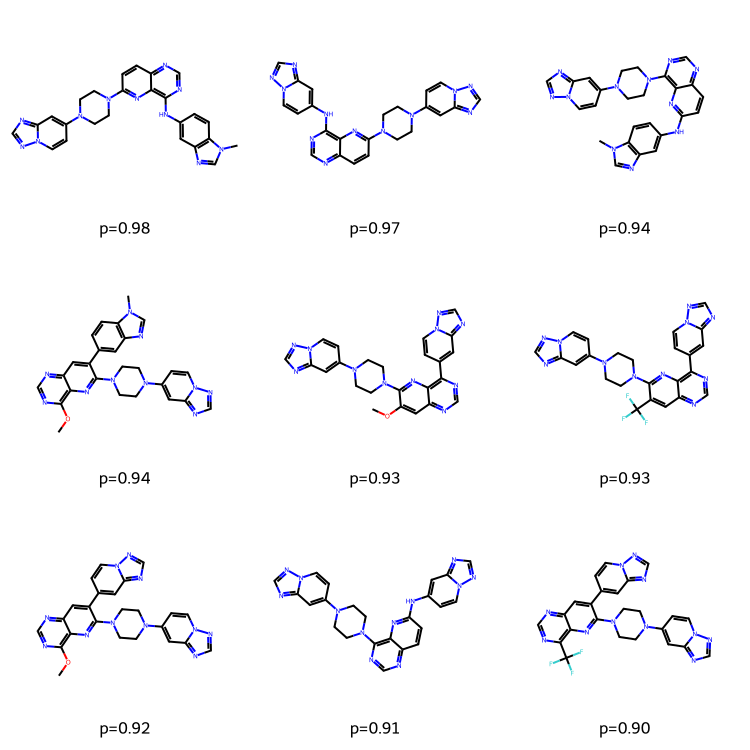

In [5]:
top_mols = [Chem.MolFromSmiles(s) for s in shortlist["canonical_smiles"].head(9)]
legends = [f"p={p:.2f}" for p in shortlist["activity_probability"].head(9)]
Draw.MolsToGridImage(top_mols, molsPerRow=3, subImgSize=(250, 250), legends=legends)

In [6]:
shortlist.to_csv("../data/processed/erbb2_candidate_shortlist.csv", index=False)
print("Sauvegardé :", len(shortlist), "candidats")

Sauvegardé : 15 candidats
